In [51]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown, Image
import warnings
from __future__ import annotations
from dataclasses import dataclass, field
from IPython.display import display, Markdown, clear_output
import ipywidgets as widgets
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from IPython.display import display, Markdown, clear_output
import ipywidgets as widgets
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Define paths
# BASE_DIR = Path('../outputs')
RESULTS_DIR = Path('../results')
CHECKPOINT_DIR = Path('../checkpoints')

print("✓ Imports successful")
print(f"✓ Results directory: {RESULTS_DIR.resolve()}")
print(f"✓ Checkpoint directory: {CHECKPOINT_DIR.resolve()}")

✓ Imports successful
✓ Results directory: C:\Projects\dr-nrt\results
✓ Checkpoint directory: C:\Projects\dr-nrt\checkpoints


In [52]:
# Helper functions
def load_json(filepath):
    """Load JSON file and return dictionary"""
    with open(filepath, 'r') as f:
        return json.load(f)

def display_json_as_table(data, title=""):
    """Display nested JSON as formatted table"""
    if title:
        display(Markdown(f"### {title}"))
    
    if isinstance(data, dict):
        df = pd.DataFrame([data]).T
        df.columns = ['Value']
        display(df)
    else:
        display(pd.DataFrame(data))

def plot_training_curves(history_data, title="Training Curves"):
    """Plot training and validation metrics over epochs"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    epochs = range(1, len(history_data['train_loss']) + 1)
    
    # Loss
    axes[0, 0].plot(epochs, history_data['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, history_data['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss Curves')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(epochs, history_data['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[0, 1].plot(epochs, history_data['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Accuracy Curves')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Kappa
    axes[1, 0].plot(epochs, history_data['val_kappa'], 'g-', label='Val Kappa', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Quadratic Kappa')
    axes[1, 0].set_title('Validation Kappa')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # AUC
    axes[1, 1].plot(epochs, history_data['val_auc'], 'purple', label='Val AUC', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('AUC')
    axes[1, 1].set_title('Validation AUC (Referable DR)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig


In [53]:
RESULTS_DIR = Path('../results')
exp_folders = [d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and d.name.startswith('exp')]
exp_folders.sort()
print(f"Found {len(exp_folders)} experiments.")
print(exp_folders)

Found 31 experiments.
['exp00_baseline', 'exp01_std_aug', 'exp02_adv_aug', 'exp03_focal_loss', 'exp04_label_smooth', 'exp05_mixup_branch3', 'exp06_cutmix', 'exp07_regression', 'exp08_gem', 'exp09_cosine_lr', 'exp100_a0_baseline_ece', 'exp101_a0b_weighted_sampler', 'exp102_a0c_offline_oversample', 'exp102_a0c_offline_oversample-v2', 'exp103_a1_ordsupcon_aptos', 'exp103_a1_ordsupcon_aptos-v2', 'exp12_opt_thresh_opA', 'exp13_pseudo_label', 'exp200_a2_ordsupcon_eyepacs', 'exp201_a2v2_freeze5_eyepacs', 'exp300_d1_dropout_cosine', 'exp501_f2_joint_ordsupcon', 'exp502_f3_joint_fixed', 'exp600_g1_corn_imagenet', 'exp605_a1v3_ordsupcon_40ep', 'exp700_h0_linear_probe_a2', 'exp701_h1_ordsupcon_d1recipe', 'exp702_h2_lpft_a2', 'exp802_i1_emd_on_d1_recipe', 'exp804_i3_swad_on_d1', 'exp806_i5_prototype_head_a2_emd']


In [54]:
def analyze_single_experiment(exp_name):
    exp_path = RESULTS_DIR / exp_name
    prefix = exp_name 
    
    display(Markdown(f"## Experiment: `{exp_name}`"))
    
    # 1. Print Classification Report
    cls_report_path = exp_path / f"{prefix}_cls_report.txt"
    if cls_report_path.exists():
        display(Markdown("### Classification Report"))
        with open(cls_report_path, 'r') as f:
            print(f.read())
    else:
        print("Classification report not found.")

    # 2. Display Images (Curves and Confusion Matrix side-by-side)
    cm_path = exp_path / f"{prefix}_cm.png"
    curves_path = exp_path / f"{prefix}_curves.png"
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    if cm_path.exists():
        axes[0].imshow(mpimg.imread(cm_path))
        axes[0].set_title("Confusion Matrix")
        axes[0].axis('off')
    else:
        axes[0].text(0.5, 0.5, 'CM not found', ha='center')
        
    if curves_path.exists():
        axes[1].imshow(mpimg.imread(curves_path))
        axes[1].set_title("Learning Curves")
        axes[1].axis('off')
    else:
        axes[1].text(0.5, 0.5, 'Curves not found', ha='center')
        
    plt.tight_layout()
    plt.show()

    # 3. Show the last few rows of the training log
    log_path = exp_path / f"{prefix}_log.csv"
    if log_path.exists():
        display(Markdown("### Training Log (Last 5 Epochs)"))
        df = pd.read_csv(log_path)
        display(df.tail(5))

In [ ]:
# Create a dropdown widget
dropdown = widgets.Dropdown(
    options=exp_folders,
    description='Experiment:',
    disabled=False,
)

output_area = widgets.Output()

def on_dropdown_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        with output_area:
            clear_output(wait=True)
            analyze_single_experiment(change['new'])

dropdown.observe(on_dropdown_change)

# Display the UI
display(dropdown, output_area)

# Initialize the first view
with output_area:
    if exp_folders:
        analyze_single_experiment(exp_folders[0])

Dropdown(description='Experiment:', options=('exp00_baseline', 'exp01_std_aug', 'exp02_adv_aug', 'exp03_focal_…

Output()

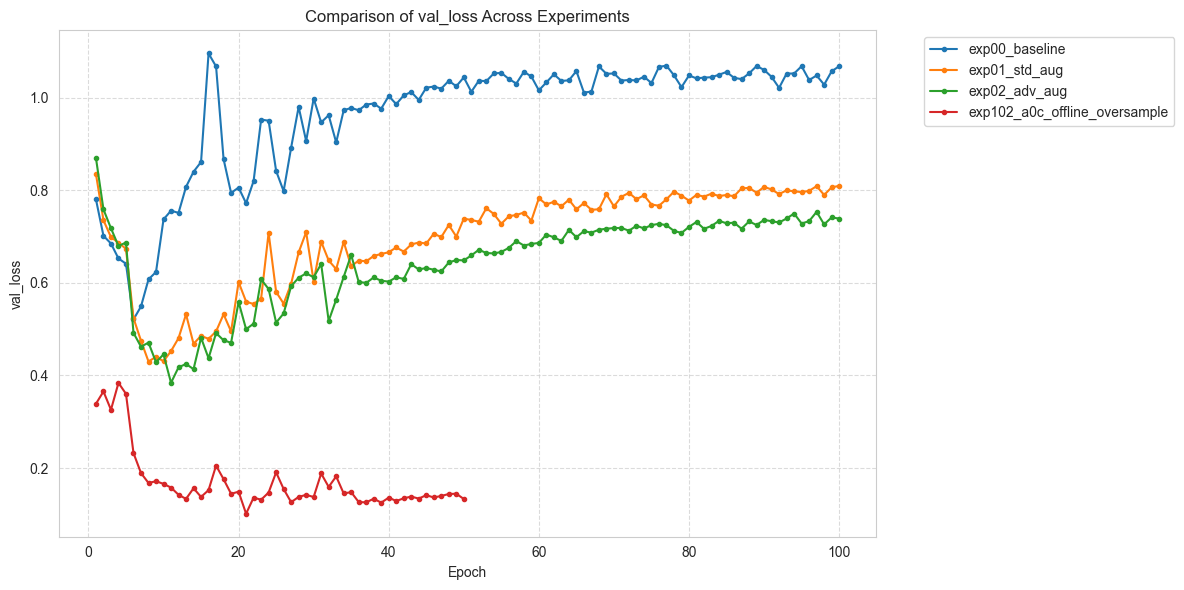

In [56]:
def compare_experiments(exp_list, metric='val_loss'):
    """
    Plots a specific metric from the _log.csv files across multiple experiments.
    """
    plt.figure(figsize=(12, 6))
    
    for exp in exp_list:
        log_path = RESULTS_DIR / exp / f"{exp}_log.csv"
        
        if log_path.exists():
            df = pd.read_csv(log_path)
            # Adjust 'epoch' to match your actual CSV column name for the x-axis
            x_axis = df['epoch'] if 'epoch' in df.columns else df.index
            
            # Check if the requested metric exists in this log
            if metric in df.columns:
                plt.plot(x_axis, df[metric], label=exp, marker='o', markersize=3)
            else:
                print(f"Metric '{metric}' not found in {exp}")
                
    plt.title(f"Comparison of {metric} Across Experiments")
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Example Usage: Compare your baseline with augmentation strategies
compare_experiments([
    'exp00_baseline', 
    'exp01_std_aug', 
    'exp02_adv_aug', 
    'exp102_a0c_offline_oversample'
], metric='val_loss') # Change to 'val_acc', 'val_kappa', or whatever columns your CSV holds

In [57]:
import pandas as pd
from pathlib import Path
import re
from IPython.display import display

RESULTS_DIR = Path('../results')
exp_folders = sorted([d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and d.name.startswith('exp')])

metric_mapping = {
    'qwk': 'QWK',
    'macro_f1': 'Macro F1',
    'f1_Severe': 'Severe F1',
    'f1_Proliferative': 'Prolif F1',
    'f1_Moderate': 'Mod F1',
    'auc_roc': 'AUC-ROC',
    'ece': 'ECE'
}

results_list = []

# Fetch and sort all experiment folders
# exp_folders = sorted([d for d in RESULTS_DIR.iterdir() if d.is_dir() and d.name.startswith('exp')])

for exp_name in exp_folders:
    log_file = RESULTS_DIR / exp_name / f"{exp_name}.log"
    
    if log_file.exists():
        exp_data = {'Exp': exp_name}
        
        with open(log_file, 'r') as f:
            content = f.read()
            
        # Extract metrics using regex to catch the float values
        for log_key, table_col in metric_mapping.items():
            match = re.search(fr"{log_key}:\s*([0-9.]+)", content)
            if match:
                exp_data[table_col] = float(match.group(1))
            else:
                exp_data[table_col] = None # Handle missing metrics gracefully
                
        results_list.append(exp_data)

df_results = pd.DataFrame(results_list)

# Function to highlight the best performing metrics
def highlight_best(s):
    if s.name == 'Exp':
        return [''] * len(s)
    # ECE (Expected Calibration Error) is typically lower-is-better. 
    # All other metrics are higher-is-better.
    if s.name == 'ECE':
        is_best = s == s.min()
    else:
        is_best = s == s.max()
        
    return ['font-weight: bold' if v else '' for v in is_best]

styled_df = df_results.style.apply(highlight_best).format(precision=4, na_rep='-')
display(styled_df)

,Exp,QWK,Macro F1,Severe F1,Prolif F1,Mod F1,AUC-ROC,ECE
0,exp08_gem,0.9127,0.7040,0.4444,0.7013,0.7911,-,-
1,exp09_cosine_lr,0.8946,0.6716,0.4096,0.7089,0.6667,-,-
2,exp100_a0_baseline_ece,0.9127,0.7040,0.4444,0.7013,0.7911,0.9462,0.0420
3,exp101_a0b_weighted_sampler,0.9031,0.6657,0.3333,0.6667,0.7746,0.9489,0.0263
4,exp102_a0c_offline_oversample,0.9096,0.7055,0.4478,0.6750,0.7748,0.9478,0.0437
5,exp103_a1_ordsupcon_aptos,0.8575,0.6356,0.4412,0.5474,0.6538,0.9389,0.0635
6,exp13_pseudo_label,0.8927,0.7138,0.5490,0.6400,0.8111,-,-
7,exp200_a2_ordsupcon_eyepacs,0.8932,0.6580,0.4167,0.6279,0.7127,0.9383,0.0520
8,exp201_a2v2_freeze5_eyepacs,0.8748,0.6354,0.3934,0.5806,0.7085,0.9377,0.0505
9,exp300_d1_dropout_cosine,0.9159,0.6945,0.3830,0.6667,0.8221,0.9518,0.0482
